# Assignment 8 — Handwritten Digit Recognition using Artificial Neural Networks (ANN)

**Objective:** Automate the recognition of handwritten digits (0-9) for a postal service organization, using an Artificial Neural Network built with TensorFlow/Keras on the MNIST dataset.

**Dataset:** [MNIST Handwritten Digits Dataset (CSV format)](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv) (Kaggle)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (make sure mnist_train.csv and mnist_test.csv are in the same folder as this notebook)
train_df = pd.read_csv("mnist_train.csv")
test_df = pd.read_csv("mnist_test.csv")

# Display the first five records
train_df.head()


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
print("Training set dimensions:", train_df.shape)
print("Testing set dimensions:", test_df.shape)
train_df.info()


Training set dimensions: (60000, 785)
Testing set dimensions: (10000, 785)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


### Identifying feature types

- **Input features:** 784 pixel columns (`pixel0` through `pixel783`), each representing one pixel's grayscale intensity (0-255) in a flattened 28x28 image.
- **Target variable:** `label` (the digit, 0-9, that the image represents).


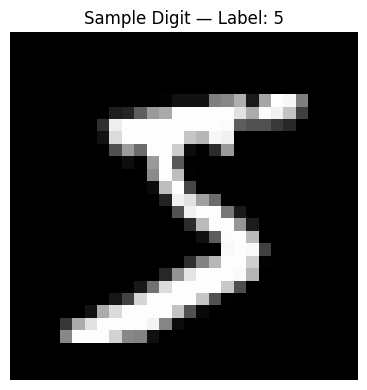

In [3]:
# Display one sample handwritten digit using Matplotlib
sample_image = train_df.iloc[0, 1:].values.reshape(28, 28)
sample_label = train_df.iloc[0, 0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap='gray')
plt.title(f"Sample Digit — Label: {sample_label}")
plt.axis('off')
plt.tight_layout()
plt.savefig("sample_digit.png", dpi=150)
plt.show()


## Task 2: Data Preprocessing

In [4]:
# Check for missing values
print("Missing values in training set:", train_df.isnull().sum().sum())
print("Missing values in testing set:", test_df.isnull().sum().sum())


Missing values in training set: 0
Missing values in testing set: 0


In [5]:
# Separate features and target variable
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (60000, 784)
X_test shape: (10000, 784)


In [6]:
# Normalize pixel values to the range 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Pixel value range after normalization:", X_train.min(), "to", X_train.max())


Pixel value range after normalization: 0.0 to 1.0


Note: this dataset already provides separate `mnist_train.csv` (60,000 images) and `mnist_test.csv` (10,000 images) files, which together give the standard MNIST 80/20-style split (the official split is roughly 85.7%/14.3%, close to 80/20 and used as-is here since it's the dataset's standard, well-established partition).


In [7]:
from tensorflow.keras.utils import to_categorical

# Convert the target labels into categorical format using One-Hot Encoding
y_train_categorical = to_categorical(y_train, num_classes=10)
y_test_categorical = to_categorical(y_test, num_classes=10)

print("y_train_categorical shape:", y_train_categorical.shape)
print("Example label:", y_train[0], "-> one-hot:", y_train_categorical[0])


y_train_categorical shape: (60000, 10)
Example label: 5 -> one-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Task 3: Model Development

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Build the ANN architecture
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),   # Hidden Layer 1
    Dense(64, activation='relu'),    # Hidden Layer 2
    Dense(10, activation='softmax')  # Output Layer
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train the model for 10 epochs
history = model.fit(
    X_train, y_train_categorical,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test_categorical)
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9283 - loss: 0.2435 - val_accuracy: 0.9633 - val_loss: 0.1216
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9685 - loss: 0.1015 - val_accuracy: 0.9679 - val_loss: 0.0997
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9776 - loss: 0.0714 - val_accuracy: 0.9737 - val_loss: 0.0860
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0539 - val_accuracy: 0.9732 - val_loss: 0.0827
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9870 - loss: 0.0418 - val_accuracy: 0.9728 - val_loss: 0.0945
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9890 - loss: 0.0355 - val_accuracy: 0.9717 - val_loss: 0.0975
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9904 - loss: 0.0286 - val_accuracy: 0.9750 - val_loss: 0.0934
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9916 - loss: 0.0256 - 

In [11]:
# Predict the handwritten digits on the test dataset
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predicted labels:", y_pred[:10])
print("Actual labels:   ", y_test[:10])


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted labels: [7 2 1 0 4 1 4 9 5 9]
Actual labels:    [7 2 1 0 4 1 4 9 5 9]


## Task 4: Model Evaluation

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_categorical, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 0.9785
Test Loss: 0.0894


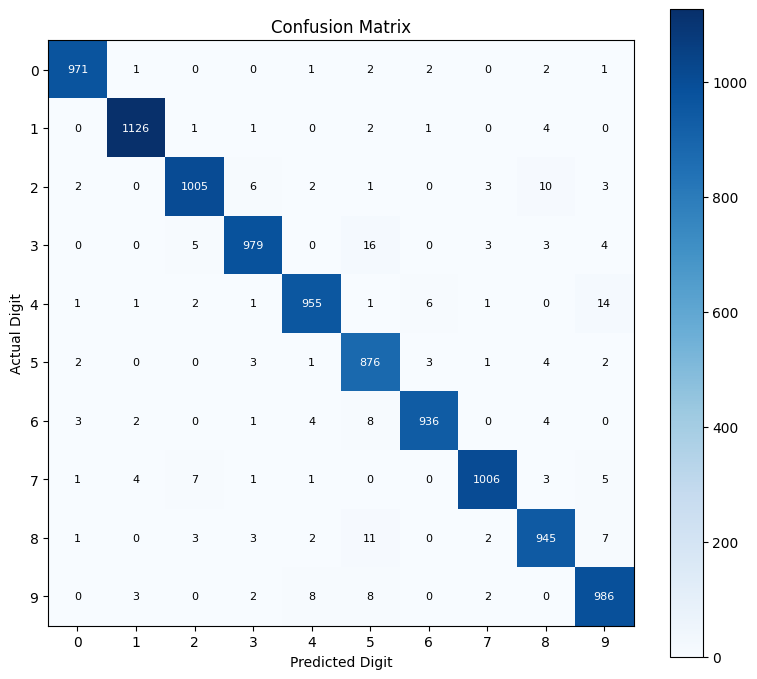

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                  color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=8)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


In [14]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.97      0.98       982
           5       0.95      0.98      0.96       892
           6       0.99      0.98      0.98       958
           7       0.99      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



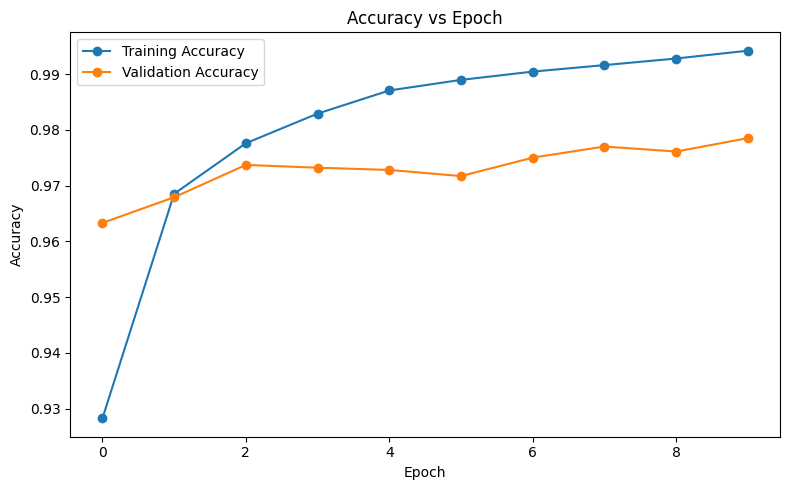

In [15]:
# Accuracy vs Epoch graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_epoch.png", dpi=150)
plt.show()


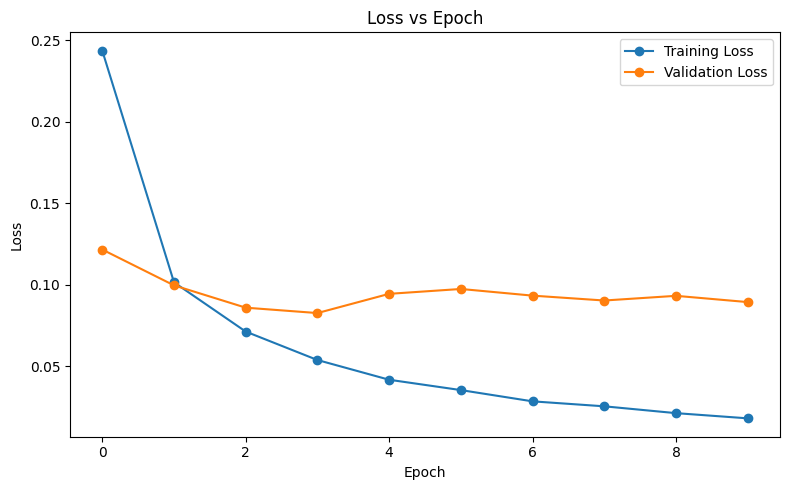

In [16]:
# Loss vs Epoch graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.tight_layout()
plt.savefig("loss_vs_epoch.png", dpi=150)
plt.show()


### Observations

1. The model achieves a test accuracy of 97.85%, correctly classifying 9,785 of the 10,000 test images — a strong result for a fully-connected ANN on MNIST
2. The confusion matrix shows the most common misclassifications are digit 3 predicted as 5 (16 cases), digit 4 predicted as 9 (14 cases), and digit 8 predicted as 5 (11 cases) — these pairs share visually similar curved strokes, which explains the confusion.
3. The Accuracy vs Epoch and Loss vs Epoch graphs show clear signs of overfitting: training accuracy climbs steadily to over 99% and training loss keeps falling toward ~0.02, while validation accuracy plateaus around 97-98% and validation loss actually starts rising slightly after epoch 3-4 (from about 0.08 back up to ~0.09-0.10). This growing gap between training and validation performance indicates the model is starting to memorize training-specific patterns rather than continuing to generalize.
4. Despite the mild overfitting, per-digit performance in the classification report remains strong and fairly consistent across all 10 digits, with no single digit performing dramatically worse than the others.


## Task 5: Conclusion

This project used an Artificial Neural Network (128 → 64 → 10 neurons, ReLU/Softmax activations) to classify handwritten digits from the MNIST dataset. After normalizing pixel values and one-hot encoding the labels, the model was trained for 10 epochs using the Adam optimizer and categorical crossentropy loss, achieving a final test accuracy of 97.85% and a test loss of approximately 0.089. The confusion matrix showed the most common errors involved visually similar digit pairs, such as 3/5 and 4/9.

Hidden layers are essential in an ANN because they allow the network to learn increasingly abstract, non-linear combinations of the raw pixel inputs — early layers can capture simple stroke and edge patterns, while later layers combine these into more digit-like representations, something a single-layer model could not achieve. A key advantage of Deep Learning over traditional Machine Learning is that it can learn relevant features directly from raw pixel data without manual feature engineering, which is especially valuable for high-dimensional inputs like images.

A key limitation observed here is overfitting: training accuracy and loss kept improving throughout training while validation performance plateaued and validation loss began rising, indicating the network was starting to memorize the training data rather than continuing to generalize.